In [20]:
%load_ext autoreload
%autoreload 2
%env https_proxy=http://proxy:80
%env http_proxy=http://proxy:80

from torchvision import models
import torch
import utils
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: https_proxy=http://proxy:80
env: http_proxy=http://proxy:80


In [21]:
# Initialize some model to use
setup = utils.system_startup()
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(**setup)
#model = models.resnet50(pretrained=False).to(**setup)
model.eval();

Currently evaluating -------------------------------:
Tuesday, 05. November 2024 09:41AM
CPUs: 8, GPUs: 1 on tg069.
GPU : NVIDIA GeForce RTX 2080 Ti


torch.Size([3, 64, 64])


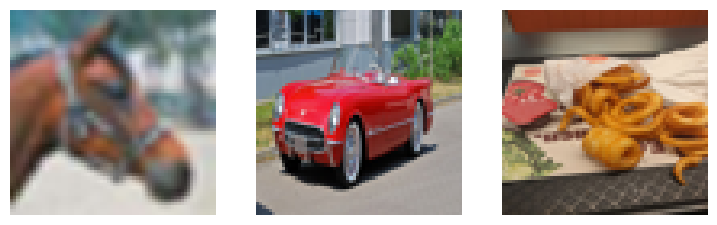

In [22]:
# Change image resolution here
image_size = (64, 64)
image_conf = [
    (utils.load_img('imgs/horse_side.png', image_size), torch.as_tensor((122,), device=setup['device'])), # some random class
    (utils.load_img('imgs/car.jpg', image_size), torch.as_tensor((817,), device=setup['device'])), # 'sports car'
    (utils.load_img('imgs/curly_fries.png', image_size), torch.as_tensor((42,), device=setup['device'])) # some random class
]
utils.plot(torch.stack([utils.denormalize(img) for (img, label) in image_conf]))

## Getting the gradient of the target - client side operation

In [23]:
loss_fn = torch.nn.CrossEntropyLoss()
def grad_for_img(img, label):
    """
    Perform a gradient calculation for a given image and label.
    Returns:
        input_gradient: list of gradients of each layer of the network with respect to the loss.
                        That's the gradient a client would send to the server for a single image.
    """
    model.zero_grad()
    learn_loss = loss_fn(model(img.unsqueeze(0)), label)
    input_gradient = torch.autograd.grad(learn_loss, model.parameters())
    input_gradient = [grad.detach() for grad in input_gradient]
    return input_gradient

# Perform a single gradient calculation for each image
image_conf = [(image, lbl, grad) for (image, lbl), grad in zip(image_conf, [grad_for_img(img, label) for img, label in image_conf])]

In [28]:
# Uncomment for Task 3
"""
image_conf = [
    (torch.zeros((3, 64, 64), device=setup['device']), torch.as_tensor((122,), device=setup['device']), torch.load(f'grads/grad_0.pt')), # some random class
    (torch.zeros((3, 64, 64), device=setup['device']), torch.as_tensor((122,), device=setup['device']), torch.load(f'grads/grad_1.pt')), # some random class
]
image_size = (64, 64)
"""

/tmp/ipykernel_2967482/3212612934.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  (torch.zeros((3, 64, 64), device=setup['device']), torch.as_tensor((122,), device=setup

'\n'

## Try to reconstruct the images from their gradients - server side operation

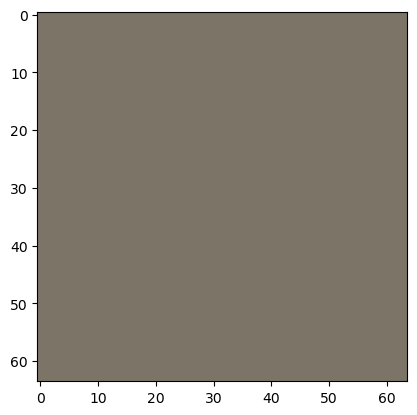

In [38]:
# number of optimization steps between logging of losses
logging_rate = 100
# maybe use a reduced frequency for logging images
image_rate = 100
def regularization_loss(reconstruction):
    # TODO 3
    return 0

def gradient_mismatch_loss(target_gradient, current_gradient):
    # TODO 2
    return (torch.cat([g.view(-1) for g in current_gradient]) - torch.cat([g.view(-1) for g in target_gradient])).abs().sum() # dummy loss

def reconstruct_image(input_gradient, iterations, labels, image_dims, alpha, lr, gt_img):  
    # fix the seed, since reconstruction success is initilization dependent
    torch.manual_seed(42)
    # start from gaussian noise
    reconstructed_img = torch.randn(image_dims, **setup).unsqueeze(0).detach().requires_grad_(True)
    optimizer = torch.optim.Adam([reconstructed_img], lr=lr)
    intermediate_images = [gt_img.unsqueeze(0)]

    for i in range(iterations):
        optimizer.zero_grad()
        model.zero_grad()
        
        # TODO 1: Perform forward pass to get the gradient, do NOT use grad_for_img here
        reconstructed_gradient = 0
        
        # Calculate the losses
        grad_loss = gradient_mismatch_loss(input_gradient, reconstructed_gradient)
        reg_loss = regularization_loss(reconstructed_img)
        reconstruction_loss = grad_loss + reg_loss * alpha

        # Perform image update
        reconstruction_loss.backward()
        reconstructed_img.grad.sign_()
        optimizer.step()

        # Logging
        if i % image_rate == 0 or i == iterations - 1:
            plt.figure(figsize=(2, 2))
            utils.plot(utils.denormalize(
                torch.stack([reconstructed_img.squeeze(0),
                             gt_img])))
            plt.show()
        if i % logging_rate == 0 or i == iterations - 1:
            print(f"Iteration {i:6}/{iterations}, lr: {lr:4.4f}, Rec. Loss: {reconstruction_loss.item():6.3f} = Grad: {grad_loss.item():6.3f} + Reg.: {reg_loss.item():6.3f} * {alpha:2.2e}")
        if i % 100 == 0 or i == iterations - 1:
            intermediate_images.append(reconstructed_img.clone())

    return torch.cat(intermediate_images)

# Reconstruct one image at a time
for (img, label, grad) in image_conf:
    iterations = 3_000
    alpha = 0.1
    lr = 0.05

    reconstructed_images = reconstruct_image(grad, iterations, label, (3, *image_size), alpha=alpha, lr=lr, gt_img=img)
    utils.plot(utils.denormalize(reconstructed_images))